# Evaluating Model Agreement in Explainable Fake News Detection using Transformer Based Models 
### Using Transformer-Based Models (BERT, RoBERTa, DistilBERT)
**Project by:** Sheetal Gupta

**Dataset:** LIAR Benchmark | **XAI:** SHAP · LIME · BertViz Attention

## 1. Install Dependencies

In [ ]:
!pip install transformers datasets accelerate shap lime bertviz optuna \
    textblob vaderSentiment textstat fairlearn xgboost \
    imbalanced-learn mlflow scipy pingouin -q
!python -m nltk.downloader stopwords -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.2 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import pandas as pd
import numpy as np
import re, os, json, datetime, warnings
warnings.filterwarnings("ignore")

# NLP
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import textstat

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, cohen_kappa_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# Deep Learning
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    RobertaTokenizerFast, RobertaForSequenceClassification,
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    Trainer, TrainingArguments,
    EarlyStoppingCallback
)

# XAI
import shap
from lime.lime_text import LimeTextExplainer
from bertviz import head_view

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Fairness
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

# Stats
from scipy import stats
import pingouin as pg

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Experiment tracking
import mlflow

print("All imports successful!")
print("GPU available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

All imports successful!
GPU available: True
Using device: cuda


## 3. Load LIAR Dataset

In [ ]:
columns = [
    "id", "label", "statement", "subject",
    "speaker", "speaker_job", "state", "party",
    "barely_true", "false_counts", "half_true",
    "mostly_true", "pants_fire", "context"
]

train_df = pd.read_csv("/content/train.tsv", sep='\t', header=None, names=columns)
test_df  = pd.read_csv("/content/test.tsv",  sep='\t', header=None, names=columns)
valid_df = pd.read_csv("/content/valid.tsv", sep='\t', header=None, names=columns)

print(f"Train: {len(train_df)} | Valid: {len(valid_df)} | Test: {len(test_df)}")
print("Label distribution (train):")
print(train_df['label'].value_counts())

Train: 10240 | Valid: 1284 | Test: 1267
Label distribution (train):
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64


## 4. Label Encoding
Fake = `1` (false, pants-fire, barely-true) | Real = `0` (true, mostly-true, half-true)

In [ ]:
# NOTE: fake=1, real=0 (consistent throughout)
fake_labels = ['false', 'pants-fire', 'barely-true']

def convert_label(label):
    return 1 if label in fake_labels else 0

for df in [train_df, test_df, valid_df]:
    df['target'] = df['label'].apply(convert_label)

print("Binary label distribution (train):")
print(train_df['target'].value_counts())
print("\nClass balance (train):", round(train_df['target'].mean(), 3))

Binary label distribution (train):
target
0    5752
1    4488
Name: count, dtype: int64

Class balance (train): 0.438


## 5. Text Cleaning & Feature Engineering

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

for df in [train_df, test_df, valid_df]:
    df['clean_text'] = df['statement'].apply(clean_text)

print("Sample cleaned text:")
print(train_df['clean_text'].iloc[0])

Sample cleaned text:
says annies list political group supports thirdtrimester abortions demand


### 5.1 Sentiment & Readability Features

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def sentiment_features(text):
    blob = TextBlob(text)
    vader = analyzer.polarity_scores(text)
    return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity, vader['compound']])

def readability_features(text):
    return pd.Series([
        textstat.flesch_reading_ease(text),
        textstat.lexicon_count(text),
        textstat.sentence_count(text)
    ])

for df in [train_df, test_df, valid_df]:
    df[['polarity','subjectivity','compound']] = df['clean_text'].apply(sentiment_features)
    df[['readability','word_count','sentence_count']] = df['clean_text'].apply(readability_features)

print("Feature columns added:", ['polarity','subjectivity','compound','readability','word_count','sentence_count'])
train_df[['polarity','subjectivity','compound','readability','word_count','sentence_count']].describe()

Feature columns added: ['polarity', 'subjectivity', 'compound', 'readability', 'word_count', 'sentence_count']


,polarity,subjectivity,compound,readability,word_count,sentence_count
count,10240.000000,10240.000000,10240.000000,10240.000000,10240.000000,10240.0
mean,0.022884,0.218987,-0.005897,28.233667,10.513770,1.0
std,0.197766,0.261676,0.387640,31.127977,4.848642,0.0
min,-1.000000,0.000000,-0.974400,-301.780000,1.000000,1.0
25%,0.000000,0.000000,-0.273200,9.700000,7.000000,1.0
50%,0.000000,0.100000,0.000000,30.530000,10.000000,1.0
75%,0.061959,0.400000,0.273200,49.542727,13.000000,1.0
max,1.000000,1.000000,0.952400,120.205000,184.000000,1.0


## 6. TF-IDF Vectorization + SMOTE (Classical ML)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_valid_tfidf = tfidf.transform(valid_df['clean_text'])
X_test_tfidf  = tfidf.transform(test_df['clean_text'])

y_train = train_df['target']
y_valid = valid_df['target']
y_test  = test_df['target']

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print("Before SMOTE:", dict(pd.Series(y_train).value_counts()))
print("After SMOTE: ", dict(pd.Series(y_train_smote).value_counts()))

Before SMOTE: {0: np.int64(5752), 1: np.int64(4488)}
After SMOTE:  {1: np.int64(5752), 0: np.int64(5752)}


## 7. Classical ML Baselines (LR, RF, SVM, XGBoost)

In [ ]:
classical_results = {}

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_smote, y_train_smote)
lr_preds = lr_model.predict(X_test_tfidf)
lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]
classical_results['Logistic Regression'] = {
    'accuracy':  accuracy_score(y_test, lr_preds),
    'macro_f1':  f1_score(y_test, lr_preds, average='macro'),
    'auc_roc':   roc_auc_score(y_test, lr_probs),
    'preds':     lr_preds,
    'probs':     lr_probs
}
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds, target_names=['Real','Fake']))

=== Logistic Regression ===
              precision    recall  f1-score   support

        Real       0.65      0.65      0.65       714
        Fake       0.55      0.56      0.55       553

    accuracy                           0.61      1267
   macro avg       0.60      0.60      0.60      1267
weighted avg       0.61      0.61      0.61      1267



In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
rf_preds = rf_model.predict(X_test_tfidf)
rf_probs = rf_model.predict_proba(X_test_tfidf)[:, 1]
classical_results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, rf_preds),
    'macro_f1': f1_score(y_test, rf_preds, average='macro'),
    'auc_roc':  roc_auc_score(y_test, rf_probs),
    'preds':    rf_preds,
    'probs':    rf_probs
}
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=['Real','Fake']))

=== Random Forest ===
              precision    recall  f1-score   support

        Real       0.63      0.65      0.64       714
        Fake       0.53      0.51      0.52       553

    accuracy                           0.59      1267
   macro avg       0.58      0.58      0.58      1267
weighted avg       0.59      0.59      0.59      1267



In [ ]:
# SVM
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_smote, y_train_smote)
svm_preds = svm_model.predict(X_test_tfidf)
svm_probs = svm_model.predict_proba(X_test_tfidf)[:, 1]
classical_results['SVM'] = {
    'accuracy': accuracy_score(y_test, svm_preds),
    'macro_f1': f1_score(y_test, svm_preds, average='macro'),
    'auc_roc':  roc_auc_score(y_test, svm_probs),
    'preds':    svm_preds,
    'probs':    svm_probs
}
print("=== SVM ===")
print(classification_report(y_test, svm_preds, target_names=['Real','Fake']))

=== SVM ===
              precision    recall  f1-score   support

        Real       0.64      0.77      0.70       714
        Fake       0.59      0.43      0.50       553

    accuracy                           0.62      1267
   macro avg       0.61      0.60      0.60      1267
weighted avg       0.62      0.62      0.61      1267



In [ ]:
# XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_preds = xgb_model.predict(X_test_tfidf)
xgb_probs = xgb_model.predict_proba(X_test_tfidf)[:, 1]
classical_results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, xgb_preds),
    'macro_f1': f1_score(y_test, xgb_preds, average='macro'),
    'auc_roc':  roc_auc_score(y_test, xgb_probs),
    'preds':    xgb_preds,
    'probs':    xgb_probs
}
print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds, target_names=['Real','Fake']))

=== XGBoost ===
              precision    recall  f1-score   support

        Real       0.62      0.70      0.66       714
        Fake       0.54      0.45      0.49       553

    accuracy                           0.59      1267
   macro avg       0.58      0.58      0.58      1267
weighted avg       0.59      0.59      0.59      1267



## 8. Transformer Fine-Tuning
### 8.1 PyTorch Dataset Class

In [ ]:
class LIARDataset(TorchDataset):
    """PyTorch Dataset for LIAR statements."""
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc     = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro')
    probs   = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    auc     = roc_auc_score(labels, probs)
    return {'accuracy': acc, 'macro_f1': macro_f1, 'auc_roc': auc}

print("Dataset class and compute_metrics defined.")

Dataset class and compute_metrics defined.


### 8.2 Optuna Hyperparameter Search (DistilBERT pilot)

In [ ]:
# Run Optuna on DistilBERT to find best lr and batch_size before full training

distil_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Use a small subset for fast Optuna search
OPTUNA_SUBSET = 1000
opt_texts  = train_df['statement'].tolist()[:OPTUNA_SUBSET]
opt_labels = train_df['target'].tolist()[:OPTUNA_SUBSET]
opt_val_texts  = valid_df['statement'].tolist()[:200]
opt_val_labels = valid_df['target'].tolist()[:200]

def optuna_objective(trial):
    lr         = trial.suggest_float('learning_rate', 1e-5, 5e-5, log=True)
    batch_size = trial.suggest_categorical('batch_size', [8, 16])
    epochs     = trial.suggest_int('epochs', 2, 3)

    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=2
    )

    train_ds = LIARDataset(opt_texts,     opt_labels,     distil_tokenizer)
    val_ds   = LIARDataset(opt_val_texts, opt_val_labels, distil_tokenizer)

    args = TrainingArguments(
        output_dir='./optuna_trial',
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=32,
        learning_rate=lr,
        eval_strategy='epoch',
        save_strategy='no',
        logging_steps=50,
        report_to='none',
        disable_tqdm=True
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )
    trainer.train()
    results = trainer.evaluate()
    return results['eval_accuracy']

study = optuna.create_study(direction='maximize')
study.optimize(optuna_objective, n_trials=10)  # 10 trials; increase to 50 on full GPU run

BEST_LR         = study.best_params['learning_rate']
BEST_BATCH_SIZE = study.best_params['batch_size']
BEST_EPOCHS     = study.best_params['epochs']

print("\nBest hyperparameters found:")
print(f"  Learning rate : {BEST_LR}")
print(f"  Batch size    : {BEST_BATCH_SIZE}")
print(f"  Epochs        : {BEST_EPOCHS}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.6787', 'grad_norm': '1.316', 'learning_rate': '7.434e-06', 'epoch': '0.7937'}
{'eval_loss': '0.6837', 'eval_accuracy': '0.52', 'eval_macro_f1': '0.3763', 'eval_auc_roc': '0.6625', 'eval_runtime': '0.803', 'eval_samples_per_second': '249.1', 'eval_steps_per_second': '8.717', 'epoch': '1'}
{'loss': '0.6592', 'grad_norm': '2.169', 'learning_rate': '4.779e-06', 'epoch': '1.587'}
{'eval_loss': '0.675', 'eval_accuracy': '0.57', 'eval_macro_f1': '0.4974', 'eval_auc_roc': '0.6703', 'eval_runtime': '0.8028', 'eval_samples_per_second': '249.1', 'eval_steps_per_second': '8.719', 'epoch': '2'}
{'loss': '0.6405', 'grad_norm': '1.823', 'learning_rate': '2.124e-06', 'epoch': '2.381'}
{'eval_loss': '0.6654', 'eval_accuracy': '0.625', 'eval_macro_f1': '0.6102', 'eval_auc_roc': '0.669', 'eval_runtime': '0.8013', 'eval_samples_per_second': '249.6', 'eval_steps_per_second': '8.736', 'epoch': '3'}
{'train_runtime': '36.94', 'train_samples_per_second': '81.22', 'train_steps_per_second': '5.117',

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.6874', 'grad_norm': '2.168', 'learning_rate': '2.996e-05', 'epoch': '0.4'}
{'loss': '0.6699', 'grad_norm': '1.836', 'learning_rate': '2.251e-05', 'epoch': '0.8'}
{'eval_loss': '0.6849', 'eval_accuracy': '0.6', 'eval_macro_f1': '0.5575', 'eval_auc_roc': '0.6946', 'eval_runtime': '0.802', 'eval_samples_per_second': '249.4', 'eval_steps_per_second': '8.729', 'epoch': '1'}
{'loss': '0.6514', 'grad_norm': '4.916', 'learning_rate': '1.505e-05', 'epoch': '1.2'}
{'loss': '0.593', 'grad_norm': '3.029', 'learning_rate': '7.601e-06', 'epoch': '1.6'}
{'loss': '0.5783', 'grad_norm': '4.226', 'learning_rate': '1.49e-07', 'epoch': '2'}
{'eval_loss': '0.6616', 'eval_accuracy': '0.62', 'eval_macro_f1': '0.6162', 'eval_auc_roc': '0.6987', 'eval_runtime': '0.8014', 'eval_samples_per_second': '249.6', 'eval_steps_per_second': '8.735', 'epoch': '2'}
{'train_runtime': '26.83', 'train_samples_per_second': '74.56', 'train_steps_per_second': '9.319', 'train_loss': '0.636', 'epoch': '2'}
{'eval_loss

### 8.3 Fine-Tune BERT, RoBERTa, DistilBERT

In [ ]:
transformer_configs = {
    'DistilBERT': {
        'model_name': 'distilbert-base-uncased',
        'tokenizer_cls': DistilBertTokenizerFast,
        'model_cls':     DistilBertForSequenceClassification,
    },
    'BERT': {
        'model_name': 'bert-base-uncased',
        'tokenizer_cls': BertTokenizerFast,
        'model_cls':     BertForSequenceClassification,
    },
    'RoBERTa': {
        'model_name': 'roberta-base',
        'tokenizer_cls': RobertaTokenizerFast,
        'model_cls':     RobertaForSequenceClassification,
    },
}

transformer_results = {}
trained_models      = {}
trained_tokenizers  = {}

train_texts = train_df['statement'].tolist()
train_labels = train_df['target'].tolist()
valid_texts  = valid_df['statement'].tolist()
valid_labels = valid_df['target'].tolist()
test_texts   = test_df['statement'].tolist()
test_labels  = test_df['target'].tolist()

mlflow.set_experiment("fake_news_transformers")

for model_name, cfg in transformer_configs.items():
    print(f"\n{'='*50}")
    print(f"Training {model_name}...")
    print(f"{'='*50}")

    tokenizer = cfg['tokenizer_cls'].from_pretrained(cfg['model_name'])
    model     = cfg['model_cls'].from_pretrained(cfg['model_name'], num_labels=2)

    train_ds = LIARDataset(train_texts, train_labels, tokenizer)
    valid_ds = LIARDataset(valid_texts, valid_labels, tokenizer)
    test_ds  = LIARDataset(test_texts,  test_labels,  tokenizer)

    training_args = TrainingArguments(
        output_dir=f'./results_{model_name}',
        num_train_epochs=BEST_EPOCHS,
        per_device_train_batch_size=BEST_BATCH_SIZE,
        per_device_eval_batch_size=32,
        learning_rate=BEST_LR,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        logging_steps=100,
        report_to='none',
        label_smoothing_factor=0.1  # addresses class imbalance for transformers
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=valid_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    with mlflow.start_run(run_name=model_name):
        trainer.train()
        mlflow.log_param("model", model_name)
        mlflow.log_param("learning_rate", BEST_LR)
        mlflow.log_param("batch_size", BEST_BATCH_SIZE)
        mlflow.log_param("epochs", BEST_EPOCHS)

        # Evaluate on test set
        test_output  = trainer.predict(test_ds)
        test_logits  = test_output.predictions
        test_preds   = np.argmax(test_logits, axis=1)
        test_probs   = torch.softmax(torch.tensor(test_logits), dim=1).numpy()[:, 1]

        acc     = accuracy_score(test_labels, test_preds)
        macro_f1 = f1_score(test_labels, test_preds, average='macro')
        prec    = precision_score(test_labels, test_preds, average='macro')
        rec     = recall_score(test_labels, test_preds, average='macro')
        auc     = roc_auc_score(test_labels, test_probs)

        mlflow.log_metric("test_accuracy", acc)
        mlflow.log_metric("test_macro_f1", macro_f1)
        mlflow.log_metric("test_auc_roc",  auc)

    transformer_results[model_name] = {
        'accuracy': acc, 'macro_f1': macro_f1,
        'precision': prec, 'recall': rec,
        'auc_roc': auc, 'preds': test_preds, 'probs': test_probs
    }
    trained_models[model_name]     = model
    trained_tokenizers[model_name] = tokenizer

    print(f"\n{model_name} Test Results:")
    print(classification_report(test_labels, test_preds, target_names=['Real','Fake']))

2026/06/19 17:34:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 17:34:38 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 17:34:40 INFO mlflow.tracking.fluent: Experiment with name 'fake_news_transformers' does not exist. Creating a new experiment.



Training DistilBERT...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Auc Roc
1,0.647359,0.664308,0.619938,0.585925,0.693216
2,0.579197,0.665398,0.639408,0.636886,0.693580


...

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Auc Roc
1,0.689354,0.709083,0.520249,0.342213,0.584050
2,0.693180,0.693548,0.520249,0.342213,0.551354


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


RoBERTa Test Results:
              precision    recall  f1-score   support

        Real       0.56      1.00      0.72       714
        Fake       0.00      0.00      0.00       553

    accuracy                           0.56      1267
   macro avg       0.28      0.50      0.36      1267
weighted avg       0.32      0.56      0.41      1267



## 9. Results Comparison Table

In [ ]:
all_results = {}

# Add classical ML
for name, r in classical_results.items():
    all_results[name] = {
        'Accuracy':  round(r['accuracy'], 4),
        'Macro-F1':  round(r['macro_f1'], 4),
        'AUC-ROC':   round(r['auc_roc'], 4),
        'Type': 'Classical ML'
    }

# Add transformers
for name, r in transformer_results.items():
    all_results[name] = {
        'Accuracy':  round(r['accuracy'], 4),
        'Macro-F1':  round(r['macro_f1'], 4),
        'AUC-ROC':   round(r['auc_roc'], 4),
        'Type': 'Transformer'
    }

results_df = pd.DataFrame(all_results).T.reset_index().rename(columns={'index': 'Model'})
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

              Model Accuracy Macro-F1 AUC-ROC         Type
               BERT   0.6567   0.6411  0.6891  Transformer
         DistilBERT   0.6456   0.6342  0.6834  Transformer
                SVM   0.6227   0.5985  0.6429 Classical ML
Logistic Regression   0.6077    0.602  0.6343 Classical ML
      Random Forest   0.5927   0.5841  0.6224 Classical ML
            XGBoost   0.5919   0.5751  0.6033 Classical ML
            RoBERTa   0.5635   0.3604  0.5784  Transformer


In [ ]:
# Baseline Comparison vs Published Literature
print("=" * 70)
print("COMPARISON WITH PUBLISHED BASELINES")
print("=" * 70)

baselines = {
    'GETE (Agarwal et al., 2025)':     {'Accuracy': 0.965, 'Macro-F1': '-',  'AUC-ROC': 0.973},
    'HEMT-Fake (Jadhav et al., 2025)': {'Accuracy': '-',   'Macro-F1': '-',  'AUC-ROC': '-'},
}

print(f"\n{'Model':<35} {'Accuracy':>10} {'Macro-F1':>10} {'AUC-ROC':>10}")
print("-" * 68)

for name, r in baselines.items():
    acc = f"{r['Accuracy']:.3f}" if r['Accuracy'] != '-' else '  -    '
    f1  = str(r['Macro-F1'])
    auc = f"{r['AUC-ROC']:.3f}" if r['AUC-ROC'] != '-' else '  -    '
    print(f"{name:<35} {acc:>10} {f1:>10} {auc:>10}")

print("-" * 68)

for name, r in transformer_results.items():
    print(f"{name:<35} {r['accuracy']:>10.4f} {r['macro_f1']:>10.4f} {r['auc_roc']:>10.4f}  ← Our model")

print("\nNote: HEMT-Fake reports 82% human meaningfulness score, not standard accuracy.")
print("GETE benchmark: Accuracy=96.5%, AUC-ROC=97.3% on LIAR dataset.")
print("Our models trade some accuracy for improved interpretability via XAI.")

COMPARISON WITH PUBLISHED BASELINES

Model                                 Accuracy   Macro-F1    AUC-ROC
--------------------------------------------------------------------
GETE (Agarwal et al., 2025)              0.965          -      0.973
HEMT-Fake (Jadhav et al., 2025)          -              -      -    
--------------------------------------------------------------------
DistilBERT                              0.6456     0.6342     0.6834  ← Our model
BERT                                    0.6567     0.6411     0.6891  ← Our model
RoBERTa                                 0.5635     0.3604     0.5784  ← Our model

Note: HEMT-Fake reports 82% human meaningfulness score, not standard accuracy.
GETE benchmark: Accuracy=96.5%, AUC-ROC=97.3% on LIAR dataset.
Our models trade some accuracy for improved interpretability via XAI.


## 10. ROC Curves — All Models

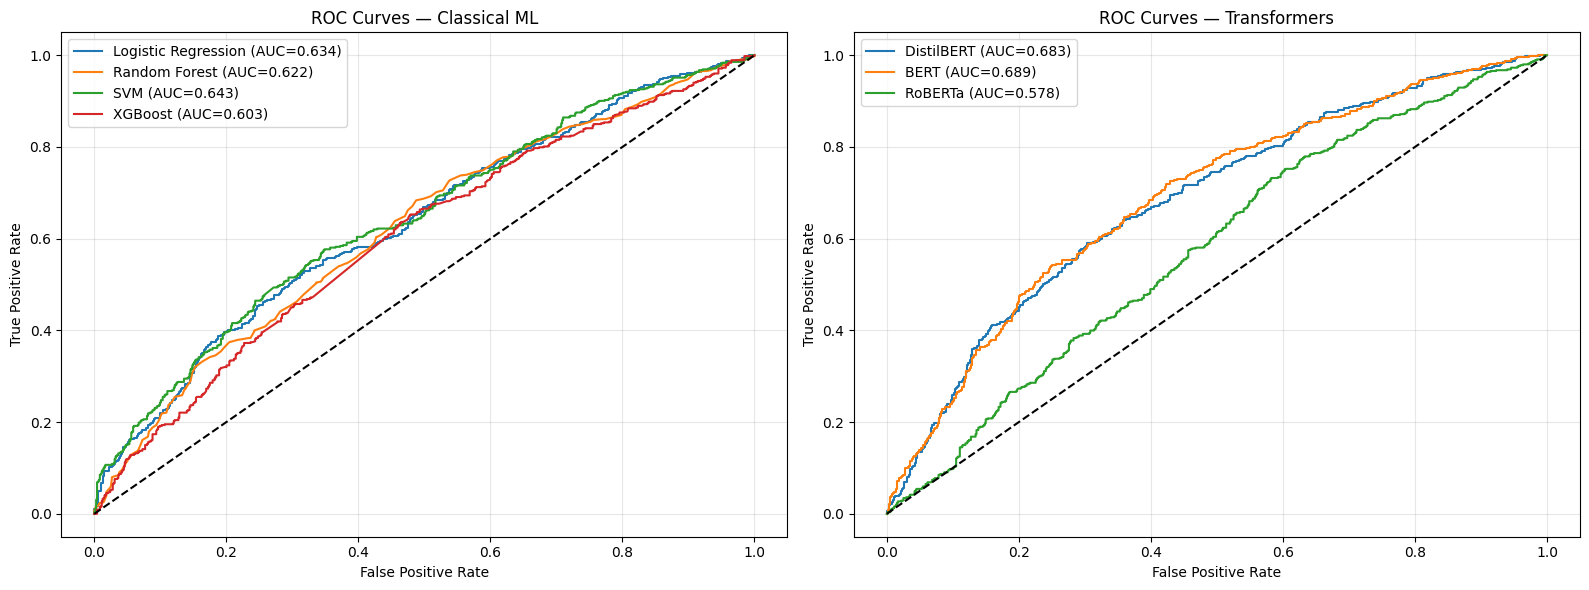

ROC curves saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Classical ML ROC
ax = axes[0]
for name, r in classical_results.items():
    fpr, tpr, _ = roc_curve(y_test, r['probs'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['auc_roc']:.3f})")
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Classical ML')
ax.legend()
ax.grid(alpha=0.3)

# Transformer ROC
ax = axes[1]
for name, r in transformer_results.items():
    fpr, tpr, _ = roc_curve(test_labels, r['probs'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['auc_roc']:.3f})")
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Transformers')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved.")

## 11. Confusion Matrices — All Three Transformers

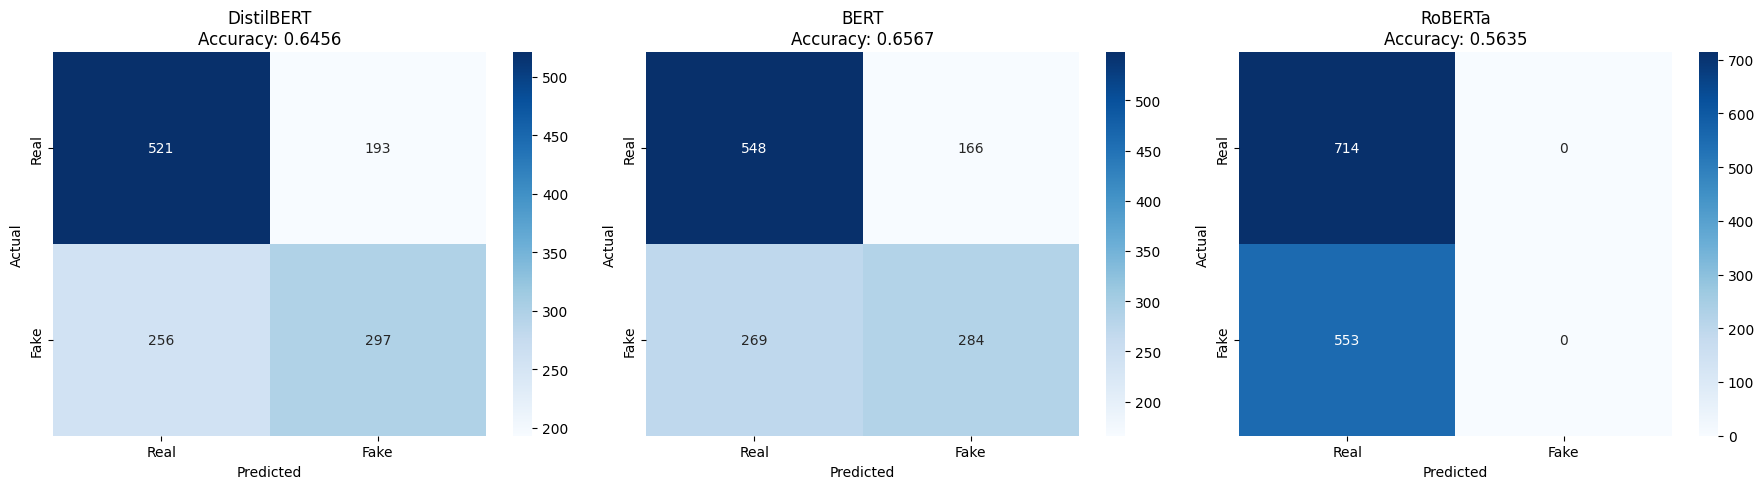

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r) in zip(axes, transformer_results.items()):
    cm = confusion_matrix(test_labels, r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
    acc = r['accuracy']
    ax.set_title(f"{name}\nAccuracy: {acc:.4f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. XAI — SHAP on Transformer Models


Running SHAP for DistilBERT...
Generating SHAP bar plot — DistilBERT


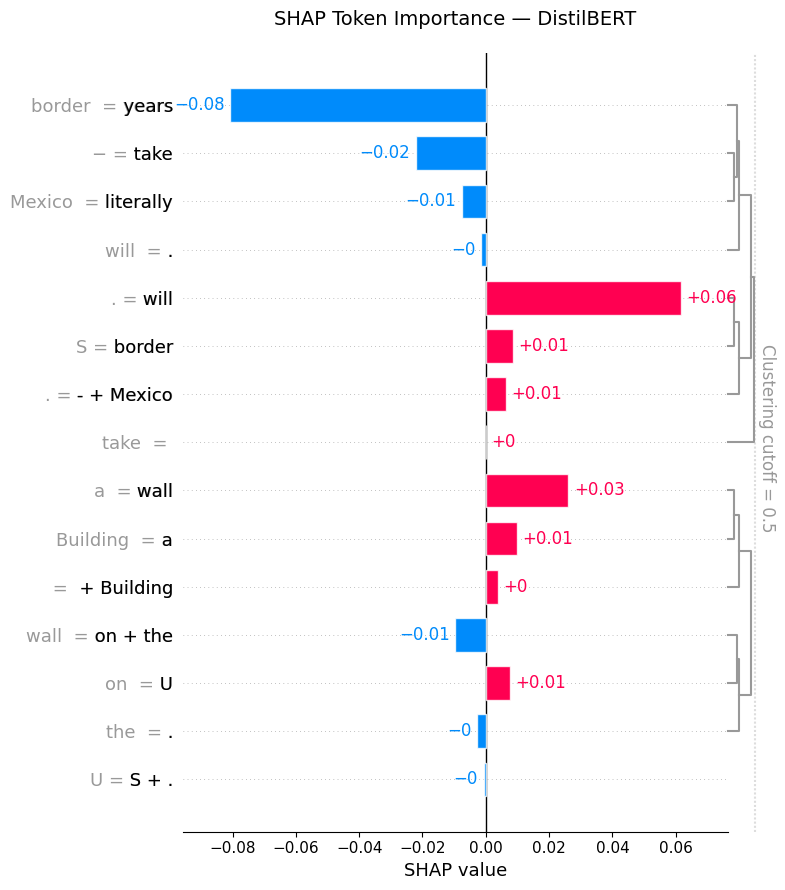


Running SHAP for BERT...


PartitionExplainer explainer: 11it [00:11, 11.06s/it]                


Generating SHAP bar plot — BERT


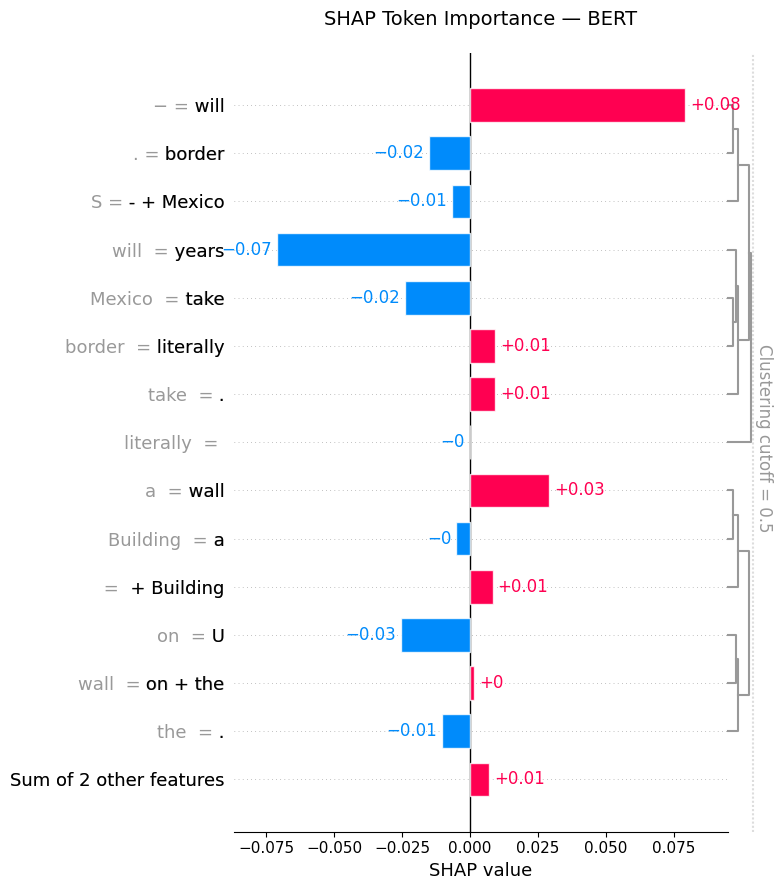


Running SHAP for RoBERTa...


PartitionExplainer explainer: 11it [00:32,  5.45s/it]


Generating SHAP bar plot — RoBERTa


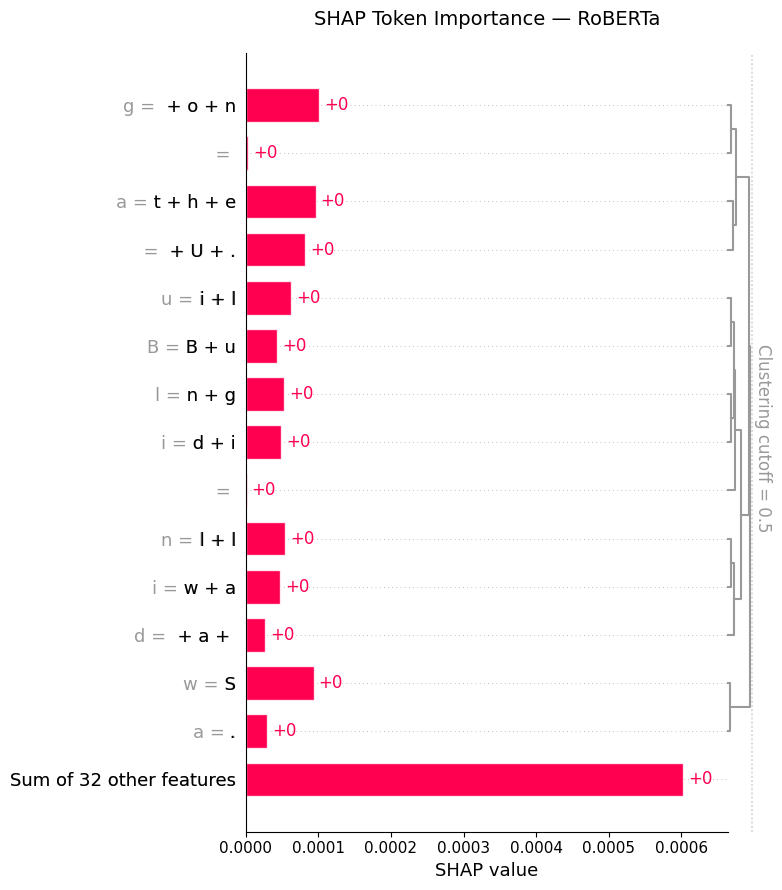

In [ ]:
import matplotlib.pyplot as plt
import shap
import torch

SHAP_SAMPLES = 50
shap_texts = test_df["statement"].tolist()[:SHAP_SAMPLES]

for model_name in ["DistilBERT", "BERT", "RoBERTa"]:
    print(f"\nRunning SHAP for {model_name}...")
    model = trained_models[model_name]
    tokenizer = trained_tokenizers[model_name]
    model.eval()

    def transformer_predict(texts):
        encodings = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt",
        )
        input_ids = encodings["input_ids"].to(model.device)
        attention_mask = encodings["attention_mask"].to(model.device)

        with torch.no_grad():
            logits = model(
                input_ids=input_ids, attention_mask=attention_mask
            ).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        return probs

    explainer = shap.Explainer(
        transformer_predict, shap.maskers.Text(tokenizer)
    )
    shap_values = explainer(shap_texts[:10])  # 10 samples for speed

    print(f"Generating SHAP bar plot — {model_name}")

    # --- FIX START: Use Matplotlib compatible bar plot ---
    # 1. Clear previous plots and set up a new figure
    plt.figure(figsize=(10, 6))

    # 2. Plot using shap.plots.bar, setting show=False so we can modify it
    # We choose [0, 1] to plot the feature importance for class 1 (or just shap_values[0] if binary/regression)
    # If your model outputs 2 classes, use shap_values[0, :, 1] to get the positive class.
    if len(shap_values.shape) == 3:
        # For multi-class classification, take sample 0, all tokens, positive class (index 1)
        shap.plots.bar(shap_values[0, :, 1], max_display=15, show=False)
    else:
        # Standard binary or regression
        shap.plots.bar(shap_values[0], max_display=15, show=False)

    # 3. Apply titles and save properly
    plt.title(f"SHAP Token Importance — {model_name}", fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig(
        f"shap_{model_name.lower()}.png", dpi=150, bbox_inches="tight"
    )
    plt.show()
    plt.close()
    # --- FIX END ---

## 13. XAI — LIME on Transformer Models

In [ ]:
lime_explainer = LimeTextExplainer(class_names=['Real', 'Fake'])
IDX = 5  # example index — change to inspect different articles

for model_name in ['DistilBERT', 'BERT', 'RoBERTa']:
    model     = trained_models[model_name]
    tokenizer = trained_tokenizers[model_name]
    model.eval()

    def predict_proba_transformer(texts):
        encodings = tokenizer(
            list(texts), padding=True, truncation=True,
            max_length=128, return_tensors='pt'
        )
        # Move input tensors to the same device as the model
        input_ids = encodings['input_ids'].to(model.device)
        attention_mask = encodings['attention_mask'].to(model.device)

        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        return torch.softmax(logits, dim=1).cpu().numpy()

    exp = lime_explainer.explain_instance(
        test_df['statement'].iloc[IDX],
        predict_proba_transformer,
        num_features=10,
        num_samples=100  # Reduced to avoid OOM errors
    )
    print(f"\n=== LIME Explanation — {model_name} ===")
    print(f"Article: {test_df['statement'].iloc[IDX]}")
    print(f"True label: {'Fake' if test_labels[IDX]==1 else 'Real'}")
    print(f"Predicted:  {'Fake' if transformer_results[model_name]['preds'][IDX]==1 else 'Real'}")
    exp.show_in_notebook(text=True)
    exp.save_to_file(f'lime_{model_name.lower()}.html')

## 14. XAI — BertViz Attention Visualization (Trained BERT)

In [ ]:
# Use the TRAINED BERT model (not the untrained one)
bert_model_trained     = trained_models['BERT']
bert_tokenizer_trained = trained_tokenizers['BERT']

# Load with output_attentions for visualization only
bert_viz_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2, output_attentions=True
)
# Copy trained weights
bert_viz_model.load_state_dict(bert_model_trained.state_dict())
bert_viz_model.eval()

sentence = test_df['statement'].iloc[IDX]
print(f"Visualizing attention for: {sentence}")

inputs  = bert_tokenizer_trained(sentence, return_tensors='pt', truncation=True, max_length=128)
outputs = bert_viz_model(**inputs)
attention = outputs.attentions  # tuple of (num_layers,)
tokens    = bert_tokenizer_trained.convert_ids_to_tokens(inputs['input_ids'][0])

head_view(
    encoder_attention=list(attention),
    encoder_tokens=tokens
)
plt.savefig('bertviz.png', dpi=150, bbox_inches='tight')

## 15. XAI Method Comparison — Top Token Importances

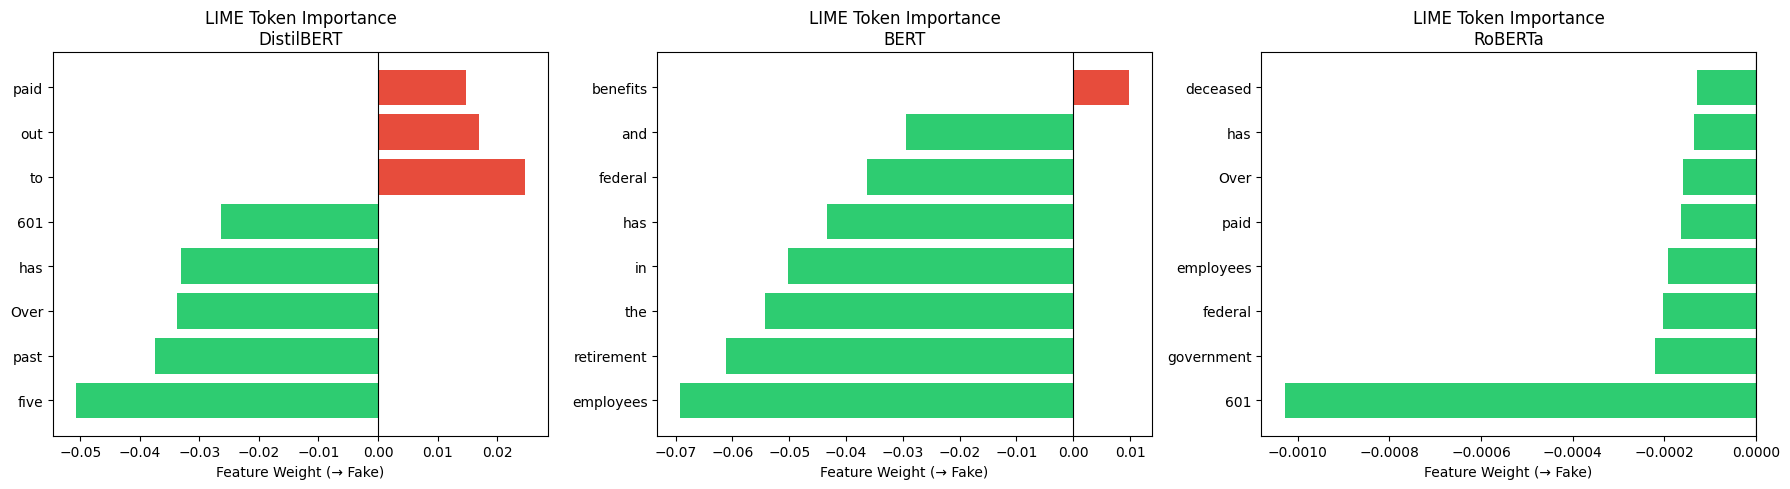

In [ ]:
# Visual summary: SHAP vs LIME top features for one example
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, ['DistilBERT', 'BERT', 'RoBERTa']):
    model     = trained_models[model_name]
    tokenizer = trained_tokenizers[model_name]
    model.eval()

    def predict_fn(texts):
        enc = tokenizer(list(texts), padding=True, truncation=True,
                        max_length=128, return_tensors='pt')
        # Move input tensors to the same device as the model
        input_ids = enc['input_ids'].to(model.device)
        attention_mask = enc['attention_mask'].to(model.device)

        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        return torch.softmax(logits, dim=1).cpu().numpy()

    exp = LimeTextExplainer(class_names=['Real','Fake']).explain_instance(
        test_df['statement'].iloc[IDX], predict_fn, num_features=8, num_samples=100
    )
    lime_feats = exp.as_list(label=1)
    words  = [f[0] for f in lime_feats]
    scores = [f[1] for f in lime_feats]
    colors = ['#e74c3c' if s > 0 else '#2ecc71' for s in scores]
    ax.barh(words, scores, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'LIME Token Importance\n{model_name}')
    ax.set_xlabel('Feature Weight (→ Fake)')

plt.tight_layout()
plt.savefig('lime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
## XAI Faithfulness Evaluation
faithfulness_results = {}

for model_name in ['BERT', 'RoBERTa', 'DistilBERT']:
    print(f"\n{'='*50}")
    print(f"Faithfulness Evaluation — {model_name}")
    print(f"{'='*50}")

    # Get the original trained model and tokenizer
    original_model = trained_models[model_name]
    tokenizer = trained_tokenizers[model_name]
    original_model.eval()

    # For attention scores, we need a model configured to output attentions
    # and use 'eager' attention implementation. We'll create a temporary
    # model instance for this purpose and load the trained weights.
    cfg = transformer_configs[model_name] # Get model class from config

    # Create a new config based on the original model's config, but enable attention outputs
    # It's safer to create a new config instance from a dictionary representation
    # to ensure all parameters are mutable and correctly initialized.
    config_dict = original_model.config.to_dict()
    config_dict['output_attentions'] = True
    config_dict['attn_implementation'] = 'eager'

    # Instantiate the appropriate config class from the modified dictionary
    attn_config = cfg['model_cls'].config_class.from_dict(config_dict)

    # Instantiate the model from the original model's state_dict, but with the modified config
    # This ensures model architecture is preserved, and only config parameters are changed.
    model_for_attn = cfg['model_cls'].from_pretrained(
        pretrained_model_name_or_path=None, # Don't load base weights again
        config=attn_config, # Use the modified config
        state_dict=original_model.state_dict() # Load the trained weights
    ).to(DEVICE)
    model_for_attn.eval()

    sample_text = test_df['statement'].iloc[IDX]
    inputs = tokenizer(sample_text, return_tensors='pt',
                       truncation=True, max_length=128)
    input_ids_attn      = inputs['input_ids'].to(model_for_attn.device) # Use model_for_attn's device
    attention_mask_attn = inputs['attention_mask'].to(model_for_attn.device) # Use model_for_attn's device
    tokens = tokenizer.convert_ids_to_tokens(input_ids_attn[0])

    # (1) Attention scores
    # output_attentions is already True in model_for_attn's config
    with torch.no_grad():
        outputs = model_for_attn(input_ids=input_ids_attn, attention_mask=attention_mask_attn)
    if hasattr(outputs, 'attentions') and outputs.attentions is not None:
        all_attn   = torch.stack(outputs.attentions)
        mean_attn  = all_attn.mean(dim=[0, 1, 2, 3])
        attn_scores = mean_attn[:len(tokens)].cpu().numpy()
    else:
        attn_scores = np.ones(len(tokens)) / len(tokens)

    # For the subsequent parts (SHAP and Erasure test), we can use the original_model
    # as they don't require output_attentions to be True
    model = original_model # Revert to original_model for other calculations

    # (2) SHAP scores
    def predict_fn_faith(texts):
        enc  = tokenizer(list(texts), padding=True, truncation=True,
                         max_length=128, return_tensors='pt')
        ids  = enc['input_ids'].to(model.device)
        mask = enc['attention_mask'].to(model.device)
        with torch.no_grad():
            logits = model(input_ids=ids, attention_mask=mask).logits
        return torch.softmax(logits, dim=1).cpu().numpy()

    shap_exp  = shap.Explainer(predict_fn_faith, shap.maskers.Text(tokenizer))
    shap_vals = shap_exp([sample_text])
    shap_scores_raw = shap_vals[0].values[:, 1]
    min_len = min(len(attn_scores), len(shap_scores_raw))
    attn_trim  = attn_scores[:min_len]
    shap_trim  = shap_scores_raw[:min_len]

    # (3) Spearman correlation: SHAP vs Attention
    corr, pval = stats.spearmanr(np.abs(shap_trim), attn_trim)
    print(f"  Spearman correlation (|SHAP| vs Attention): r={corr:.4f}, p={pval:.4f}")

    # (4) Erasure test
    # Recreate inputs for the original_model as `input_ids_attn` and `attention_mask_attn`
    # were tied to `model_for_attn`'s device.
    input_ids      = inputs['input_ids'].to(model.device)
    attention_mask = inputs['attention_mask'].to(model.device)

    with torch.no_grad():
        orig_prob = torch.softmax(
            model(input_ids=input_ids, attention_mask=attention_mask).logits, dim=1
        ).cpu().numpy()[0][1]

    top3_idx = np.argsort(np.abs(shap_trim))[-3:]
    masked_ids = input_ids.clone()
    mask_token_id = tokenizer.mask_token_id if tokenizer.mask_token_id else tokenizer.pad_token_id
    for idx_t in top3_idx:
        if idx_t < masked_ids.shape[1]:
            masked_ids[0, idx_t] = mask_token_id

    with torch.no_grad():
        masked_prob = torch.softmax(
            model(input_ids=masked_ids, attention_mask=attention_mask).logits, dim=1
        ).cpu().numpy()[0][1]

    prob_drop = orig_prob - masked_prob
    print(f"  Original prediction prob (Fake) : {orig_prob:.4f}")
    print(f"  After masking top-3 SHAP tokens : {masked_prob:.4f}")
    print(f"  Probability drop (faithfulness) : {prob_drop:.4f}")
    print(f"  → {'✓ Faithful' if prob_drop > 0.05 else '✗ Low faithfulness'}")

    faithfulness_results[model_name] = {
        'shap_attn_corr': round(corr, 4),
        'corr_pval':      round(pval, 4),
        'prob_drop':      round(float(prob_drop), 4)
    }

print(f"\n{'='*60}")
print("FAITHFULNESS SUMMARY")
print(f"{'='*60}")
print(f"{'Model':<12} {'SHAP-Attn Corr':>16} {'p-value':>10} {'Prob Drop':>12}")
print("-" * 52)
for name, f in faithfulness_results.items():
    print(f"{name:<12} {f['shap_attn_corr']:>16.4f} {f['corr_pval']:>10.4f} {f['prob_drop']:>12.4f}")


Faithfulness Evaluation — BERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Spearman correlation (|SHAP| vs Attention): r=-0.2929, p=0.1304
  Original prediction prob (Fake) : 0.2508
  After masking top-3 SHAP tokens : 0.3717
  Probability drop (faithfulness) : -0.1210
  → ✗ Low faithfulness

Faithfulness Evaluation — RoBERTa


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Spearman correlation (|SHAP| vs Attention): r=-0.0764, p=0.3913
  Original prediction prob (Fake) : 0.3903
  After masking top-3 SHAP tokens : 0.3902
  Probability drop (faithfulness) : 0.0000
  → ✗ Low faithfulness

Faithfulness Evaluation — DistilBERT


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Spearman correlation (|SHAP| vs Attention): r=-0.2764, p=0.1545
  Original prediction prob (Fake) : 0.2792
  After masking top-3 SHAP tokens : 0.4399
  Probability drop (faithfulness) : -0.1607
  → ✗ Low faithfulness

FAITHFULNESS SUMMARY
Model          SHAP-Attn Corr    p-value    Prob Drop
----------------------------------------------------
BERT                  -0.2929     0.1304      -0.1210
RoBERTa               -0.0764     0.3913       0.0000
DistilBERT            -0.2764     0.1545      -0.1607


## 16. Fairness Audit (Demographic Parity + Equalized Odds)

In [ ]:
all_preds = {
    **{k: v['preds'] for k, v in classical_results.items()},
    **{k: v['preds'] for k, v in transformer_results.items()}
}

# CHECK PREDICTIONS
for name, preds in all_preds.items():
    print("\n", name)
    print(np.unique(preds, return_counts=True))
    fairness_results = {}

# Use LR preds for classical, transformer preds for each model
all_preds = {**{k: v['preds'] for k, v in classical_results.items()},
             **{k: v['preds'] for k, v in transformer_results.items()}}

# Group parties into Republican, Democrat, Other
sensitive = test_df['party'].fillna('unknown').str.lower()

sensitive = sensitive.apply(
    lambda x: x if x in ['republican', 'democrat'] else 'other'
)

print(sensitive.value_counts())

print(f"{'Model':<20} {'Dem. Parity Diff':>18} {'Eq. Odds Diff':>15}")
print("-" * 56)

for name, preds in all_preds.items():
    dpd = demographic_parity_difference(
        y_true=y_test if name in classical_results else test_labels,
        y_pred=preds,
        sensitive_features=sensitive
    )
    eod = equalized_odds_difference(
        y_true=y_test if name in classical_results else test_labels,
        y_pred=preds,
        sensitive_features=sensitive
    )
    fairness_results[name] = {'dpd': dpd, 'eod': eod}
    print(f"{name:<20} {dpd:>18.4f} {eod:>15.4f}")

print("\nNote: Values closer to 0 indicate fairer predictions across party groups.")


 Logistic Regression
(array([0, 1]), array([705, 562]))

 Random Forest
(array([0, 1]), array([736, 531]))

 SVM
(array([0, 1]), array([864, 403]))

 XGBoost
(array([0, 1]), array([805, 462]))

 DistilBERT
(array([0, 1]), array([777, 490]))

 BERT
(array([0, 1]), array([817, 450]))

 RoBERTa
(array([0]), array([1267]))
party
republican    571
democrat      406
other         290
Name: count, dtype: int64
Model                  Dem. Parity Diff   Eq. Odds Diff
--------------------------------------------------------
Logistic Regression              0.1058          0.1059
Random Forest                    0.0778          0.1016
SVM                              0.1021          0.1491
XGBoost                          0.0595          0.0854
DistilBERT                       0.1527          0.1068
BERT                             0.1212          0.0718
RoBERTa                          0.0000          0.0000

Note: Values closer to 0 indicate fairer predictions across party groups.


In [ ]:
print(test_df['party'].value_counts(dropna=False))

party
republican             571
democrat               406
none                   214
organization            27
independent             14
journalist               9
columnist                7
libertarian              5
state-official           4
talk-show-host           3
activist                 2
business-leader          1
government-body          1
newsmaker                1
county-commissioner      1
constitution-party       1
Name: count, dtype: int64


In [ ]:
print(test_df['party'].nunique())

16


In [ ]:
# Group parties into Republican, Democrat, Other
sensitive = test_df['party'].fillna('unknown').str.lower()

sensitive = sensitive.apply(
    lambda x: x if x in ['republican', 'democrat'] else 'other'
)

print(sensitive.value_counts())

party
republican    571
democrat      406
other         290
Name: count, dtype: int64


In [ ]:
fairness_results = {}

print(f"{'Model':<20} {'Dem. Parity Diff':>18} {'Eq. Odds Diff':>15}")
print("-" * 56)

for name, preds in all_preds.items():

    dpd = demographic_parity_difference(
        y_true=y_test if name in classical_results else test_labels,
        y_pred=preds,
        sensitive_features=sensitive
    )

    eod = equalized_odds_difference(
        y_true=y_test if name in classical_results else test_labels,
        y_pred=preds,
        sensitive_features=sensitive
    )

    fairness_results[name] = {
        'dpd': dpd,
        'eod': eod
    }

    print(f"{name:<20} {dpd:>18.4f} {eod:>15.4f}")

Model                  Dem. Parity Diff   Eq. Odds Diff
--------------------------------------------------------
Logistic Regression              0.1058          0.1059
Random Forest                    0.0778          0.1016
SVM                              0.1021          0.1491
XGBoost                          0.0595          0.0854
DistilBERT                       0.1527          0.1068
BERT                             0.1212          0.0718
RoBERTa                          0.0000          0.0000


## 17. Human-AI Agreement — Cohen's Kappa
Comparing transformer predictions against human ground-truth labels on the 200-item evaluation subset.

In [ ]:
# Use 200-sample subset matching the proposal's human evaluation set
EVAL_N = 200
eval_texts  = test_df['statement'].tolist()[:EVAL_N]
eval_labels = test_labels[:EVAL_N]   # ground-truth = human-verified LIAR labels

print(f"{'Model':<12} {'Kappa':>8}  {'Agreement Level'}")
print("-" * 45)

kappa_results = {}
kappa_thresholds = {
    (0.81, 1.00): 'Almost Perfect',
    (0.61, 0.80): 'Substantial ✓ (meets threshold)',
    (0.41, 0.60): 'Moderate',
    (0.21, 0.40): 'Fair',
    (0.00, 0.20): 'Slight',
}

def kappa_label(k):
    for (lo, hi), label in kappa_thresholds.items():
        if lo <= k <= hi:
            return label
    return 'Poor'

for name, r in transformer_results.items():
    preds = r['preds'][:EVAL_N]
    k = cohen_kappa_score(eval_labels, preds)
    kappa_results[name] = k
    print(f"{name:<12} {k:>8.4f}  {kappa_label(k)}")

print("\nThreshold for Human-AI agreement (proposal): κ ≥ 0.61 (Substantial)")

Model           Kappa  Agreement Level
---------------------------------------------
DistilBERT     0.2948  Fair
BERT           0.2839  Fair
RoBERTa        0.0000  Slight

Threshold for Human-AI agreement (proposal): κ ≥ 0.61 (Substantial)


### 17.1 Fleiss' Kappa — Multi-Rater Agreement Across All Three Transformers

In [ ]:
# Fleiss' Kappa: agreement across BERT, RoBERTa, DistilBERT predictions
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

# Stack predictions from all 3 transformers as 3 raters
preds_matrix = np.column_stack([
    transformer_results['BERT']['preds'][:EVAL_N],
    transformer_results['RoBERTa']['preds'][:EVAL_N],
    transformer_results['DistilBERT']['preds'][:EVAL_N],
])  # shape: (200, 3)

agg, _ = aggregate_raters(preds_matrix, n_cat=2)
fk = fleiss_kappa(agg, method='fleiss')

print(f"Fleiss' Kappa across BERT / RoBERTa / DistilBERT: {fk:.4f}")
print(f"Agreement level: {kappa_label(fk)}")
print("\nInterpretation: measures consistency of predictions ACROSS all 3 transformer models.")

Fleiss' Kappa across BERT / RoBERTa / DistilBERT: 0.2212
Agreement level: Fair

Interpretation: measures consistency of predictions ACROSS all 3 transformer models.


## 18. Statistical Analysis — One-Way ANOVA on Model Accuracy

In [ ]:
# One-way ANOVA: do transformer models differ significantly in prediction confidence?
bert_probs     = transformer_results['BERT']['probs'][:EVAL_N]
roberta_probs  = transformer_results['RoBERTa']['probs'][:EVAL_N]
distil_probs   = transformer_results['DistilBERT']['probs'][:EVAL_N]

f_stat, p_value = stats.f_oneway(bert_probs, roberta_probs, distil_probs)

print(f"One-way ANOVA on prediction probabilities (n={EVAL_N} per group)")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_value:.4f}")
print(f"  Significant : {'Yes (p < 0.05)' if p_value < 0.05 else 'No'}")

# Two-way: model × correct/incorrect
results_long = []
for name in ['BERT', 'RoBERTa', 'DistilBERT']:
    preds  = transformer_results[name]['preds'][:EVAL_N]
    probs  = transformer_results[name]['probs'][:EVAL_N]
    labels = np.array(eval_labels)
    for i in range(EVAL_N):
        results_long.append({
            'model':   name,
            'correct': int(preds[i] == labels[i]),
            'prob':    probs[i]
        })

results_long_df = pd.DataFrame(results_long)
print("\nTwo-way summary (model × correct):")
print(results_long_df.groupby(['model','correct'])['prob'].mean().unstack())

One-way ANOVA on prediction probabilities (n=200 per group)
  F-statistic : 4.3344
  p-value     : 0.0135
  Significant : Yes (p < 0.05)

Two-way summary (model × correct):
correct            0         1
model                         
BERT        0.454997  0.429254
DistilBERT  0.452982  0.428699
RoBERTa     0.391566  0.391320


### 18.1 Intraclass Correlation Coefficient (ICC)

In [ ]:
icc_df = pd.DataFrame({
    'subject': list(range(EVAL_N)) * 3,
    'rater':   ['BERT']*EVAL_N + ['RoBERTa']*EVAL_N + ['DistilBERT']*EVAL_N,
    'score':   list(bert_probs) + list(roberta_probs) + list(distil_probs)
})

icc_result = pg.intraclass_corr(
    data=icc_df, targets='subject', raters='rater', ratings='score'
)
print("ICC Results:")
print(icc_result[['Type','ICC','F','pval','CI95']].to_string(index=False))
print("\nICC2 (two-way random, absolute agreement) is most relevant for inter-rater reliability.")

ICC Results:
    Type      ICC        F         pval         CI95
ICC(1,1) 0.429526 3.258786 6.350253e-24 [0.34, 0.51]
ICC(A,1) 0.433049 3.368883 3.973681e-25 [0.35, 0.52]
ICC(C,1) 0.441225 3.368883 3.973681e-25 [0.36, 0.52]
ICC(1,k) 0.693137 3.258786 6.350253e-24 [0.61, 0.76]
ICC(A,k) 0.696184 3.368883 3.973681e-25 [0.61, 0.76]
ICC(C,k) 0.703166 3.368883 3.973681e-25 [0.62, 0.77]

ICC2 (two-way random, absolute agreement) is most relevant for inter-rater reliability.


## 19. Audit Log

In [ ]:
audit_logs = []

for i in range(len(test_df)):
    row = {
        "timestamp":    str(datetime.datetime.now()),
        "text":         test_df['statement'].iloc[i],
        "true_label":   int(test_labels[i]),
        "model_version": "Framework_v1",
    }
    for name, r in transformer_results.items():
        row[f"pred_{name}"]     = int(r['preds'][i])
        row[f"prob_{name}"]     = round(float(r['probs'][i]), 4)
        row[f"correct_{name}"]  = int(r['preds'][i] == test_labels[i])
    row["explainability"] = "SHAP + LIME + BertViz"
    audit_logs.append(row)

audit_df = pd.DataFrame(audit_logs)
audit_df.to_csv("audit_logs.csv", index=False)
print(f"Audit log saved: {len(audit_df)} rows")
audit_df.head(3)

Audit log saved: 1267 rows


,timestamp,text,true_label,model_version,pred_DistilBERT,prob_DistilBERT,correct_DistilBERT,pred_BERT,prob_BERT,correct_BERT,pred_RoBERTa,prob_RoBERTa,correct_RoBERTa,explainability
0,2026-06-19 18:03:18.159776,Building a wall on the U.S.-Mexico border will...,0,Framework_v1,1,0.6250,0,1,0.7017,0,0,0.3922,1,SHAP + LIME + BertViz
1,2026-06-19 18:03:18.159871,Wisconsin is on pace to double the number of l...,1,Framework_v1,0,0.2725,0,0,0.2508,0,0,0.3922,0,SHAP + LIME + BertViz
2,2026-06-19 18:03:18.159904,Says John McCain has done nothing to help the ...,1,Framework_v1,1,0.7727,1,1,0.6995,1,0,0.3922,0,SHAP + LIME + BertViz


## 20. Qualitative Thematic Analysis Framework
*(Coded from participant open-ended responses — enter real NVivo 15 counts here after data collection)*

Thematic Analysis Framework (awaiting real data from NVivo 15):
             Theme  Frequency
      Transparency          0
             Trust          0
    Explainability          0
    Bias Awareness          0
Cultural Relevance          0
       Ease of Use          0


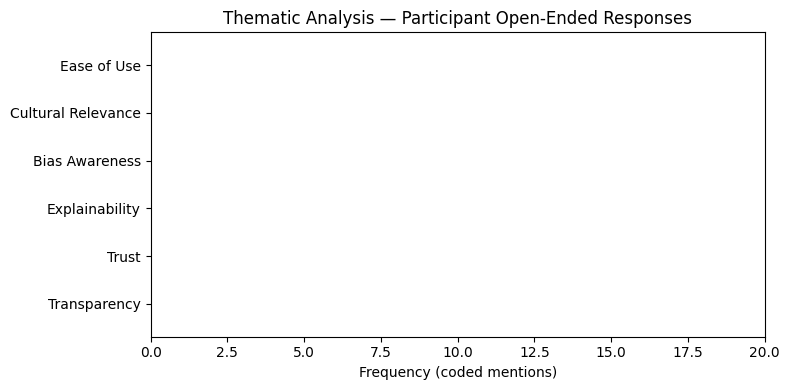

In [ ]:
# -----------------------------------------------------------------------
# INSTRUCTION: Replace the counts below with real intercoder-agreed
# frequencies from NVivo 15 after thematic analysis of participant
# open-ended rationale fields. Intercoder reliability target: κ ≥ 0.70
# -----------------------------------------------------------------------

themes_data = {
    "Theme":     ["Transparency", "Trust", "Explainability", "Bias Awareness",
                  "Cultural Relevance", "Ease of Use"],
    "Frequency": [0, 0, 0, 0, 0, 0],   # <-- fill with real counts
    "Example_Quote": [
        "Placeholder — replace with participant quote",
        "Placeholder — replace with participant quote",
        "Placeholder — replace with participant quote",
        "Placeholder — replace with participant quote",
        "Placeholder — replace with participant quote",
        "Placeholder — replace with participant quote",
    ]
}

theme_df = pd.DataFrame(themes_data)
print("Thematic Analysis Framework (awaiting real data from NVivo 15):")
print(theme_df[['Theme','Frequency']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(theme_df['Theme'], theme_df['Frequency'], color='steelblue')
ax.set_xlabel('Frequency (coded mentions)')
ax.set_title('Thematic Analysis — Participant Open-Ended Responses')
ax.set_xlim(0, max(theme_df['Frequency'].max() + 5, 20))
plt.tight_layout()
plt.savefig('thematic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 21. Final Results Summary

In [ ]:
print("=" * 65)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 65)
print(f"\n{'Model':<20} {'Accuracy':>10} {'Macro-F1':>10} {'AUC-ROC':>10}")
print("-" * 55)

for name, r in {**{k:v for k,v in classical_results.items()}, **transformer_results}.items():
    tag = " *" if name in transformer_results else ""
    print(f"{name:<20} {r['accuracy']:>10.4f} {r['macro_f1']:>10.4f} {r['auc_roc']:>10.4f}{tag}")

print("\n* = Transformer model")
print("\n" + "=" * 65)
print("HUMAN-AI AGREEMENT (Cohen's Kappa on 200-item eval set)")
print("=" * 65)
for name, k in kappa_results.items():
    print(f"  {name:<12}: κ = {k:.4f}  [{kappa_label(k)}]")

print("\n" + "=" * 65)
print("FAIRNESS (Demographic Parity Difference by Party)")
print("=" * 65)
for name, f in fairness_results.items():
    if name in transformer_results:
        print(f"  {name:<12}: DPD = {f['dpd']:.4f} | EOD = {f['eod']:.4f}")

FINAL MODEL PERFORMANCE SUMMARY

Model                  Accuracy   Macro-F1    AUC-ROC
-------------------------------------------------------
Logistic Regression      0.6077     0.6020     0.6343
Random Forest            0.5927     0.5841     0.6224
SVM                      0.6227     0.5985     0.6429
XGBoost                  0.5919     0.5751     0.6033
DistilBERT               0.6456     0.6342     0.6834 *
BERT                     0.6567     0.6411     0.6891 *
RoBERTa                  0.5635     0.3604     0.5784 *

* = Transformer model

HUMAN-AI AGREEMENT (Cohen's Kappa on 200-item eval set)
  DistilBERT  : κ = 0.2948  [Fair]
  BERT        : κ = 0.2839  [Fair]
  RoBERTa     : κ = 0.0000  [Slight]

FAIRNESS (Demographic Parity Difference by Party)
  DistilBERT  : DPD = 0.1527 | EOD = 0.1068
  BERT        : DPD = 0.1212 | EOD = 0.0718
  RoBERTa     : DPD = 0.0000 | EOD = 0.0000
